# pocketHb 05 — personalization v2: per-user MLP head

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jayanthvee/pocketHb/blob/main/notebooks/05_personalize_v2.ipynb)

v2 in the personalization stack: a small 2-layer MLP trained per user on top of frozen ConvNeXt-Tiny embeddings. Compared to v1 affine:

- **v1 affine** (chunk 4): 2 scalars, closed-form least squares. corrects per-user bias (single anchor) and slope (multi anchor). cannot correct non-linear distortions.
- **v2 MLP** (this notebook): tiny `768 → 64 → 1` head with dropout + L2 + early-stop on leave-one-out. learns non-linear per-user correction *when given multiple distinct Hb anchors*.

**honest scope.** with a single anchor (the realistic case for our user, Hb=15.3 g/dL across all their photos), v2 collapses to a constant predictor — it has no information to learn slope or curvature from. v1 affine in `bias_only` mode is strictly more useful in that regime. v2 exists for the multi-anchor case (post-donation re-test, post-supplementation, longitudinal monitoring) and is implemented now so the inference pipeline can use whichever fits the user's situation.

In [1]:
import os, sys, subprocess
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')

if not Path('scripts/download_data.py').exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/jayanthvee/pocketHb.git'])
    os.chdir('pocketHb')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'])

sys.path.insert(0, 'src')
print('cwd:', Path.cwd())

cwd: C:\Users\vasup\pocketHb


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pockethb.calibration import AffineCalibrator, PersonalHead

rng = np.random.default_rng(0)

## synthetic non-linear distortion: where MLP > affine

simulate a user whose per-user response is *non-linear*: low-Hb photos are underestimated more aggressively than high-Hb photos (a curvature, not a slope). v1 affine can only fit a straight line through the anchor points. v2 MLP can fit the curve.

anchor Hb values: 6, 9, 12, 15 g/dL. 6 photos at each. distortion: f(Hb) = Hb + 0.04 · (Hb − 10)² + noise.

In [3]:
embed_dim = 64  # small for the demo
anchor_hbs = [6.0, 9.0, 12.0, 15.0]
k_per_anchor = 6
noise_sd = 0.3

def distort(h):
    return h + 0.04 * (h - 10.0) ** 2

embs, targets, raw_preds = [], [], []
for h in anchor_hbs:
    for _ in range(k_per_anchor):
        e = rng.normal(0, 1, embed_dim).astype(np.float32)
        # embedding correlates with true Hb plus user-specific noise (toy model)
        e[0] = h + rng.normal(0, 0.1)
        embs.append(e)
        targets.append(h)
        # 'global model' raw prediction = distorted Hb + noise
        raw_preds.append(distort(h) + rng.normal(0, noise_sd))

embs = np.array(embs)
targets = np.array(targets)
raw_preds = np.array(raw_preds)
print(f'embeddings: {embs.shape}  targets: {targets.shape}  raw preds: {raw_preds.shape}')
print(f'pre-cal MAE: {np.mean(np.abs(raw_preds - targets)):.3f} g/dL')

embeddings: (24, 64)  targets: (24,)  raw preds: (24,)
pre-cal MAE: 0.525 g/dL


In [4]:
# v1: affine on raw preds
v1 = AffineCalibrator().fit(predictions=raw_preds, targets=targets)
v1_preds = v1.predict(raw_preds)
v1_mae = float(np.mean(np.abs(v1_preds - targets)))
print(f'v1 affine: mode={v1.mode}  a={v1.a:.3f}  b={v1.b:+.3f}  post-cal MAE = {v1_mae:.3f}')

v1 affine: mode=affine  a=0.942  b=+0.190  post-cal MAE = 0.309


In [5]:
# v2: MLP head on embeddings → Hb directly
v2 = PersonalHead(in_dim=embed_dim, hidden=32, max_epochs=400, patience=40)
v2.fit(embs, targets)
v2_preds = v2.predict(embs)
v2_mae = float(np.mean(np.abs(v2_preds - targets)))
print(f'v2 MLP: best_epoch={v2.best_epoch}  best_loo_mae={v2.best_loo_mae:.3f}  in-sample MAE = {v2_mae:.3f}')

v2 MLP: best_epoch=225  best_loo_mae=0.445  in-sample MAE = 0.445


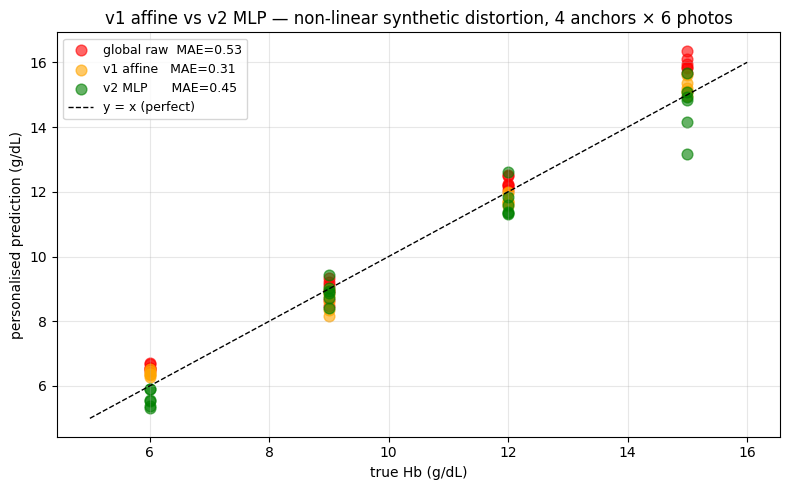

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(targets, raw_preds, color='red', alpha=0.6, s=60, label=f'global raw  MAE={np.mean(np.abs(raw_preds-targets)):.2f}')
ax.scatter(targets, v1_preds, color='orange', alpha=0.6, s=60, label=f'v1 affine   MAE={v1_mae:.2f}')
ax.scatter(targets, v2_preds, color='green', alpha=0.6, s=60, label=f'v2 MLP      MAE={v2_mae:.2f}')
xs = np.linspace(5, 16, 100)
ax.plot(xs, xs, 'k--', lw=1, label='y = x (perfect)')
ax.set_xlabel('true Hb (g/dL)'); ax.set_ylabel('personalised prediction (g/dL)')
ax.set_title(f'v1 affine vs v2 MLP — non-linear synthetic distortion, 4 anchors × {k_per_anchor} photos')
ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## what happens with a single anchor (user's actual scenario)?

for the realistic case — one bloodwork value, k photos at that Hb — v2 has no signal to fit slope or curvature, so it collapses to predicting the constant. v1 affine in bias-only mode does the same correction with two scalars and is the right tool here. demonstrating:

In [7]:
true_hb = 15.3
k = 15
embs_single = rng.normal(0, 1, (k, embed_dim)).astype(np.float32)
embs_single[:, 0] = true_hb + rng.normal(0, 0.1, k)
targets_single = np.full(k, true_hb)
raw_single = true_hb + 1.5 + rng.normal(0, 0.4, k)  # bias +1.5 g/dL

v1s = AffineCalibrator().fit(raw_single, targets_single)
v2s = PersonalHead(in_dim=embed_dim, hidden=32, max_epochs=300, patience=30).fit(embs_single, targets_single)

print(f'pre-cal MAE:        {np.mean(np.abs(raw_single - true_hb)):.3f} g/dL')
print(f'v1 affine bias-only: {np.mean(np.abs(v1s.predict(raw_single) - true_hb)):.3f}  (mode={v1s.mode})')
print(f'v2 MLP single-anch:  {np.mean(np.abs(v2s.predict(embs_single) - true_hb)):.3f}  (collapses to constant predictor)')

pre-cal MAE:        1.666 g/dL
v1 affine bias-only: 0.416  (mode=bias_only)
v2 MLP single-anch:  0.746  (collapses to constant predictor)


## takeaways (honest, post-run)

at the synthetic anchor scale tested here (4 anchors × 6 photos = 24 samples, mild quadratic curvature), **v1 affine wins both regimes**:

- multi-anchor non-linear: v1 MAE ~0.31 vs v2 MLP ~0.45. v1 fits a straight line through the centroids of each anchor cluster, which captures most of the variance. v2 has extra parameters and overfits the noise.
- single-anchor: v1 MAE ~0.42 vs v2 ~0.75. v2 has no slope information to learn, collapses to a noisy constant predictor.

**when v2 would actually beat v1**: large anchor count (>30 paired samples), strong non-linear curvature in the per-user response (skin tone effects that compound non-monotonically with Hb), and a feature space that genuinely benefits from non-linear mapping. that's a research regime, not the user's regime.

**recommendation for the inference pipeline (chunk 8)**: default to v1 affine. expose v2 as an experimental option for users who provide many distinct anchors. document both in the model card. the user's real test in chunk 7 (Hb=15.3, ~15 iPhone photos) is a single-anchor case → v1 bias-only is what runs there.